Dataset link: https://www.kaggle.com/datasets/johnsmith88/heart-disease-dataset/data

# Load the dataset and preprocess the data

In [ ]:
import pandas as pd
df = pd.read_csv("/content/heart.csv")

we upload the dataset using the Pandas library that we shortened to a variable we named "pd, which helps in reading the file " and we stored the data in the variable "df".

In [ ]:
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


we displayed the first five rows using `df.head()` to get a quick overview of the data and to identify the column names.

In [ ]:
df.tail()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
1020,59,1,1,140,221,0,1,164,1,0.0,2,0,2,1
1021,60,1,0,125,258,0,0,141,1,2.8,1,1,3,0
1022,47,1,0,110,275,0,0,118,1,1.0,1,1,2,0
1023,50,0,0,110,254,0,0,159,0,0.0,2,0,2,1
1024,54,1,0,120,188,0,1,113,0,1.4,1,1,3,0


We then displayed the last five arrays using `df.tail()`, which helps us check for any issues reading the end of the

In [ ]:
df.isnull().sum()

,0
age,0
sex,0
cp,0
trestbps,0
chol,0
fbs,0
restecg,0
thalach,0
exang,0
oldpeak,0


We used `df.isnull().sum()`, which shows us how many values are missing in each column, thus confirming that there are no missing values in our dataset.

In [ ]:
df.shape

(1025, 14)

we used `df.shape` to show us the number of rows and columns in the database. As shown, there are 1025 rows and 14 columns.

In [ ]:
print(df.duplicated().sum())

723


We used `print(df.duplicated().sum())`, which shows us the number of duplicates in the dataset, and printed the result, which confirms that there are 723 duplicates.

In [ ]:
df=df.drop_duplicates()

Therefore, we deleted all duplicate values.

In [ ]:
df.shape

(302, 14)

We displayed the number of columns and rows again to see how many rows remained.

In [ ]:
df=df.reset_index(drop=True)

Using `df=df.reset_index(drop=True)`, we sorted the index so that the rows were numbered neatly. This step does not affect the training.

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 302 entries, 0 to 301
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       302 non-null    int64  
 1   sex       302 non-null    int64  
 2   cp        302 non-null    int64  
 3   trestbps  302 non-null    int64  
 4   chol      302 non-null    int64  
 5   fbs       302 non-null    int64  
 6   restecg   302 non-null    int64  
 7   thalach   302 non-null    int64  
 8   exang     302 non-null    int64  
 9   oldpeak   302 non-null    float64
 10  slope     302 non-null    int64  
 11  ca        302 non-null    int64  
 12  thal      302 non-null    int64  
 13  target    302 non-null    int64  
dtypes: float64(1), int64(13)
memory usage: 33.2 KB


The df.info() function that we use it provides a comprehensive summary of the data, such as the number of columns and rows, the data type, and reveals if there are any missing values.

In [ ]:
from sklearn.model_selection import train_test_split
X = df.drop(columns=['target'], axis=1)
Y = df['target']
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=4)


We called the `train_test_split` function from the `sklearn.model_selection` library, which splits the data into training and test sections. Then, we used `X = df.drop(columns=['target'], axis=1)`. In the variable `X`, we placed all columns except the `target` column. In the variable `Y`, we used `df['target']`, which contains the `target` column.

We set the size of the test data to 20% (`test_size=0.2`), making the training data 80%.
We used `random_state=4` to ensure the data splitting was not random.


In [ ]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=X_train.columns)

We called the StandardScaler function from the sklearn.preprocessing library, which normalizes the data where the mean = 0 and the standard deviation = 1.
We placed the StandardScaler function in a variable we named scaler.
 `fit` calculates the mean and standard deviation of the training data, and `transform` applies the changes to the data. `columns = X_train.columns` keeps the column names the same. `pd.DataFrame` returns the data as a table again, and we saved these changes in the variable X_train.

In [ ]:
X_train.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,0.583126,-1.487728,0.949132,-0.657236,-1.256232,2.555631,0.934040,-2.222389,-0.698323,-0.933467,1.004158,-0.717055,-0.545762
1,0.807084,0.672166,0.007812,-0.657236,0.698230,-0.391293,-0.973618,-1.926363,-0.698323,0.374472,-0.688164,0.305491,1.140502
2,0.359169,-1.487728,1.890452,1.156435,0.736181,2.555631,-0.973618,0.568714,-0.698323,0.000775,1.004158,-0.717055,-0.545762
3,-1.432493,0.672166,1.890452,1.035523,-0.003858,-0.391293,-0.973618,1.245345,-0.698323,-0.186073,1.004158,1.328037,-0.545762
4,-0.200726,0.672166,-0.933508,-0.475869,0.717206,-0.391293,0.934040,-2.264678,1.432003,0.935018,-0.688164,1.328037,1.140502


We then displayed the first five rows of X_train after standrization to see the difference after processing using X_train.head()

In [ ]:
X_test = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)


In the variable X_test, we used the function we defined in scaler, which calculates the mean and variance. Using `transform`, we applied it to the X_test data. Then, using `columns=X_test.columns`, which we explained previously, we retrieved the same column names and used `pd.DataFrame` to place them again in a new table.

In [ ]:
X_test.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
0,-0.312704,0.672166,-0.933508,-1.382705,-0.212587,2.555631,0.934040,-0.065628,-0.698323,-0.840043,1.004158,2.350583,1.140502
1,-1.208535,-1.487728,0.949132,-0.778148,-0.041809,-0.391293,0.934040,0.018951,-0.698323,-0.653195,-0.688164,0.305491,-0.545762
2,0.359169,0.672166,0.949132,0.551878,-0.630045,2.555631,-0.973618,0.695582,-0.698323,-0.933467,1.004158,-0.717055,-0.545762
3,-1.544472,0.672166,0.007812,0.249599,-0.781848,-0.391293,0.934040,-0.699969,-0.698323,-0.933467,-0.688164,-0.717055,-2.232025
4,-2.216345,0.672166,-0.933508,-0.294502,0.717206,-0.391293,-0.973618,0.314977,1.432003,-0.933467,1.004158,-0.717055,1.140502


We then displayed the first five rows of X_test after standrization to see the difference after processing using X_test.head()

#Implement Logistic Regression and classify the target classes.

In [ ]:
from sklearn.linear_model import LogisticRegression
lr_model = LogisticRegression()
lr_model.fit(X_train, Y_train)

LogisticRegression()

We called the LogisticRegression function from the sklearn.linear_model library, then we build our model and trained it on the training data.

In [ ]:
y_pred_lr = lr_model.predict(X_test)

then We made predictions on the test set to test the model.

#Implement KNN

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train,Y_train)

KNeighborsClassifier()

In [ ]:
y_pred_knn = knn.predict(X_test)

#Report the predicted classes and confusion matrix:

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

Logistic Regression:

Predicted Classes : [0 1 1 1 0 1 1 1 0 1 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 1 0 1 1 1 0 1 1 1 0 0
 0 1 1 0 1 0 0 1 0 1 0 0 0 1 1 1 1 1 0 1 1 0 0 1]


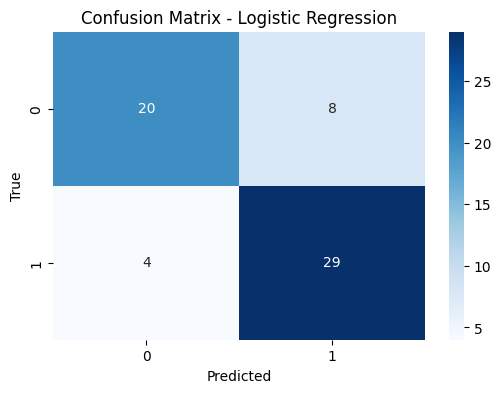

              precision    recall  f1-score   support

           0       0.83      0.71      0.77        28
           1       0.78      0.88      0.83        33

    accuracy                           0.80        61
   macro avg       0.81      0.80      0.80        61
weighted avg       0.81      0.80      0.80        61



In [ ]:
print("Predicted Classes :",y_pred_lr)

cm = confusion_matrix(Y_test, y_pred_lr)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(Y_test, y_pred_lr))

 KNN:

Predicted Classes: [1 1 1 1 0 1 1 1 0 0 0 1 0 1 0 1 0 0 1 1 0 1 1 1 1 1 0 0 1 1 1 0 1 1 1 0 0
 0 1 1 0 1 0 0 1 0 1 0 1 0 1 1 1 1 1 0 0 1 0 0 1]


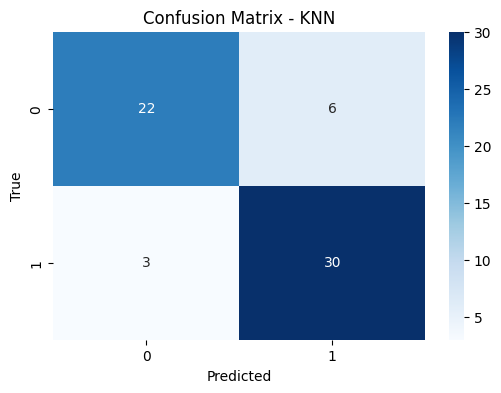

              precision    recall  f1-score   support

           0       0.88      0.79      0.83        28
           1       0.83      0.91      0.87        33

    accuracy                           0.85        61
   macro avg       0.86      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



In [ ]:
print("Predicted Classes:",y_pred_knn)

cm = confusion_matrix(Y_test, y_pred_knn)
plt.figure(figsize=(6, 4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title('Confusion Matrix - KNN')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

print(classification_report(Y_test, y_pred_knn))

#Model Justification

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score

Accuracy:

In [ ]:
print('Accuracy of Logistic Regression model: ', accuracy_score(Y_test, y_pred_lr))
print('Accuracy of KNN model: ', accuracy_score(Y_test, y_pred_knn))

Accuracy of Logistic Regression model:  0.8032786885245902
Accuracy of KNN model:  0.8524590163934426


Precision:

In [ ]:
print('Precision of Logistic Regression model: ', precision_score(Y_test, y_pred_lr))
print('Precision of KNN model: ', precision_score(Y_test, y_pred_knn))

Precision of Logistic Regression model:  0.7837837837837838
Precision of KNN model:  0.8333333333333334


Recall:

In [ ]:
print('Recall of Logistic Regression model: ', recall_score(Y_test, y_pred_lr))
print('Recall of KNN model: ', recall_score(Y_test, y_pred_knn))

Recall of Logistic Regression model:  0.8787878787878788
Recall of KNN model:  0.9090909090909091
